# Stack Overflow Retention, EDA

I want to figure out what predicts whether a new Stack Overflow contributor stays active 30 days and 180 days after their first post. A new contributor here means someone whose first post (question or answer) falls in the study window.

The window runs from 2018-01-01 through 2022-09-25. That cutoff was set by the BigQuery public dataset, not by me. It covers 57 monthly cohorts and 2.37M total new contributors. Of those, 1.77M posted a question first, and the question-first sub-cohort is what the modeling work focuses on.

This notebook loads the five parquet files produced by the SQL pipeline, joins them into one analytics dataset, prints the headline numbers, plots feature distributions, and reports a naive treatment-vs-control comparison. The naive comparison is biased on purpose, it makes the case for the propensity-score, IPW, and 2SLS work in the next notebook.

Nothing in this notebook does causal inference. The lift numbers in Section 5 conflate treatment with question-quality confounding and should not be read as causal estimates.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

# db_dtypes registers BigQuery's dbdate dtype with pandas; without this, .to_pandas()
# on a parquet whose date columns were produced by the BQ client raises a TypeError.
import db_dtypes  # noqa: F401

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

DATA_DIR = '../data/processed'

## 1. Load and inspect each parquet

Five files, one per SQL step. The first four are user-level (one row per cohort user, sometimes restricted to question-first). The fifth is a 24-row hour-of-day lookup that will be joined onto the user-level data as an instrument.

In [2]:
cohort    = pq.read_table(f'{DATA_DIR}/cohort.parquet').to_pandas()
retention = pq.read_table(f'{DATA_DIR}/retention.parquet').to_pandas()
funnel    = pq.read_table(f'{DATA_DIR}/funnel.parquet').to_pandas()
features  = pq.read_table(f'{DATA_DIR}/features.parquet').to_pandas()
treatment = pq.read_table(f'{DATA_DIR}/treatment.parquet').to_pandas()

for name, df in [('cohort', cohort), ('retention', retention), ('funnel', funnel),
                  ('features', features), ('treatment', treatment)]:
    print(f'{name:10s} {len(df):>10,} rows x {df.shape[1]:>2} cols')

cohort      2,369,254 rows x  5 cols
retention   2,369,254 rows x  9 cols
funnel      1,772,120 rows x  8 cols
features    1,772,126 rows x 13 cols
treatment          24 rows x  5 cols


In [3]:
print('cohort:'); print(cohort.head(3)); print()
print('retention:'); print(retention.head(3)); print()
print('funnel:'); print(funnel.head(3)); print()
print('features:'); print(features.head(3)); print()
print('treatment:'); print(treatment)

cohort:
   user_id cohort_month first_post_date first_post_type                     first_tag
0  2369725   2018-01-01      2018-01-01        question  python|numpy|vtk|itk|medical
1  5699197   2018-01-01      2018-01-01          answer                           NaN
2  8282595   2018-01-01      2018-01-01          answer                           NaN

retention:
   user_id cohort_month first_post_date  active_d30  active_d180  d180_observable  post_count_d1_d30  post_count_d180_d210 data_snapshot_date
0  9161137   2018-01-01      2018-01-01           1            0                1                  1                     0         2022-09-25
1  7995905   2018-01-01      2018-01-01           0            0                1                  0                     0         2022-09-25
2  9161298   2018-01-01      2018-01-01           0            0                1                  0                     0         2022-09-25

funnel:
   user_id cohort_month first_post_date  first_question_id 

## 2. Build the master analytics dataset

The modeling target is the question-first sub-cohort, roughly 1.77M of the 2.37M total. Answer-first contributors (the other 27%) don't have a received-answer-to-your-first-question funnel by construction, so I'm leaving them for a separate analysis.

The join: features inner-joined with funnel on user_id (both already restricted to question-first), then inner-joined with retention on user_id (retention covers the full cohort, so this acts as the restriction), then left-joined with the treatment lookup on hour_of_day_utc. Each user picks up the global got-answer-within-24h rate for the hour they happened to post at, which becomes the instrument for the IV analysis later.

In [4]:
master = (
    features
    .merge(
        funnel.drop(columns=['cohort_month', 'first_post_date', 'first_question_id']),
        on='user_id', how='inner'
    )
    .merge(
        retention.drop(columns=['cohort_month', 'first_post_date']),
        on='user_id', how='inner'
    )
    .merge(
        treatment[['hour_of_day_utc', 'treatment_rate_24h']],
        on='hour_of_day_utc', how='left'
    )
    .rename(columns={'treatment_rate_24h': 'hour_instrument_rate'})
)

print(f'Master analytics dataset: {len(master):,} rows x {master.shape[1]} cols')
print(f'  dropped from features ({len(features):,} -> {len(master):,}): {len(features) - len(master):,}')
print()
print('Columns:')
for col in master.columns:
    print(f'  {col:30s} {str(master[col].dtype):20s} nulls={master[col].isna().sum():>5,}')

Master analytics dataset: 1,772,119 rows x 24 cols
  dropped from features (1,772,126 -> 1,772,119): 7

Columns:
  user_id                        Int64                nulls=    0
  cohort_month                   dbdate               nulls=    0
  first_post_date                dbdate               nulls=    0
  first_question_id              Int64                nulls=    0
  title_length                   Int64                nulls=    0
  body_length                    Int64                nulls=    0
  has_code_block                 Int64                nulls=    0
  has_link                       Int64                nulls=    0
  has_image                      Int64                nulls=    0
  num_tags                       Int64                nulls=    0
  hour_of_day_utc                Int64                nulls=    0
  day_of_week                    Int64                nulls=    0
  is_weekend                     Int64                nulls=    0
  hours_to_first_answer      

## 3. Headline numbers

These are the stats I want to anchor the case-study writeup on. The retention numbers in particular are worth reading slowly. Around three quarters of new contributors never post again in their first month, and the observable D180 rate is in the single digits. Stack Overflow has always had a brutal new-user retention problem, this puts a number on it.

In [5]:
obs = master[master['d180_observable'] == 1]

print('=== HEADLINE NUMBERS ===\n')
print(f'Question-first cohort users:             {len(master):>10,}')
print(f'  observable for D180 outcome:           {len(obs):>10,}  ({len(obs)/len(master)*100:5.1f}%)')
print()
print('Engagement with first question:')
print(f'  got any answer ever:                   {master["got_any_answer"].mean()*100:5.1f}%')
print(f'  got answer within 24h:                 {master["got_answer_within_24h"].mean()*100:5.1f}%')
print(f'  got answer within 1h:                  {master["got_answer_within_1h"].mean()*100:5.1f}%')
print()
print('Retention outcomes:')
print(f'  active D30 (overall):                  {master["active_d30"].mean()*100:5.1f}%')
print(f'  active D180 (observable subset):       {obs["active_d180"].mean()*100:5.1f}%')
print(f'  D30 to D180 decay:                     {(master["active_d30"].mean() - obs["active_d180"].mean())*100:5.1f} pp')
print()
print('Features at first post:')
print(f'  body had code block:                   {master["has_code_block"].mean()*100:5.1f}%')
print(f'  body had link:                         {master["has_link"].mean()*100:5.1f}%')
print(f'  body had image:                        {master["has_image"].mean()*100:5.1f}%')
print(f'  posted on a weekend:                   {master["is_weekend"].mean()*100:5.1f}%')
print(f'  median title length (chars):           {int(master["title_length"].median()):>5}')
print(f'  median body length (chars):            {int(master["body_length"].median()):>5}')
print(f'  median num_tags:                       {int(master["num_tags"].median()):>5}')

=== HEADLINE NUMBERS ===

Question-first cohort users:              1,772,119
  observable for D180 outcome:            1,531,825  ( 86.4%)

Engagement with first question:
  got any answer ever:                    73.9%
  got answer within 24h:                  61.7%
  got answer within 1h:                   45.3%

Retention outcomes:
  active D30 (overall):                   24.0%
  active D180 (observable subset):         4.8%
  D30 to D180 decay:                      19.3 pp

Features at first post:
  body had code block:                    78.4%
  body had link:                          21.8%
  body had image:                          5.4%
  posted on a weekend:                    19.5%
  median title length (chars):              56
  median body length (chars):             1047


  median num_tags:                           3


## 4. Feature distributions

Six panels. Title length, body length on a log scale (the raw distribution has a long right tail and looks like nothing on a linear axis), tag count, posting hour in UTC, day of week, and the binary features (code block, link, image, weekend post).

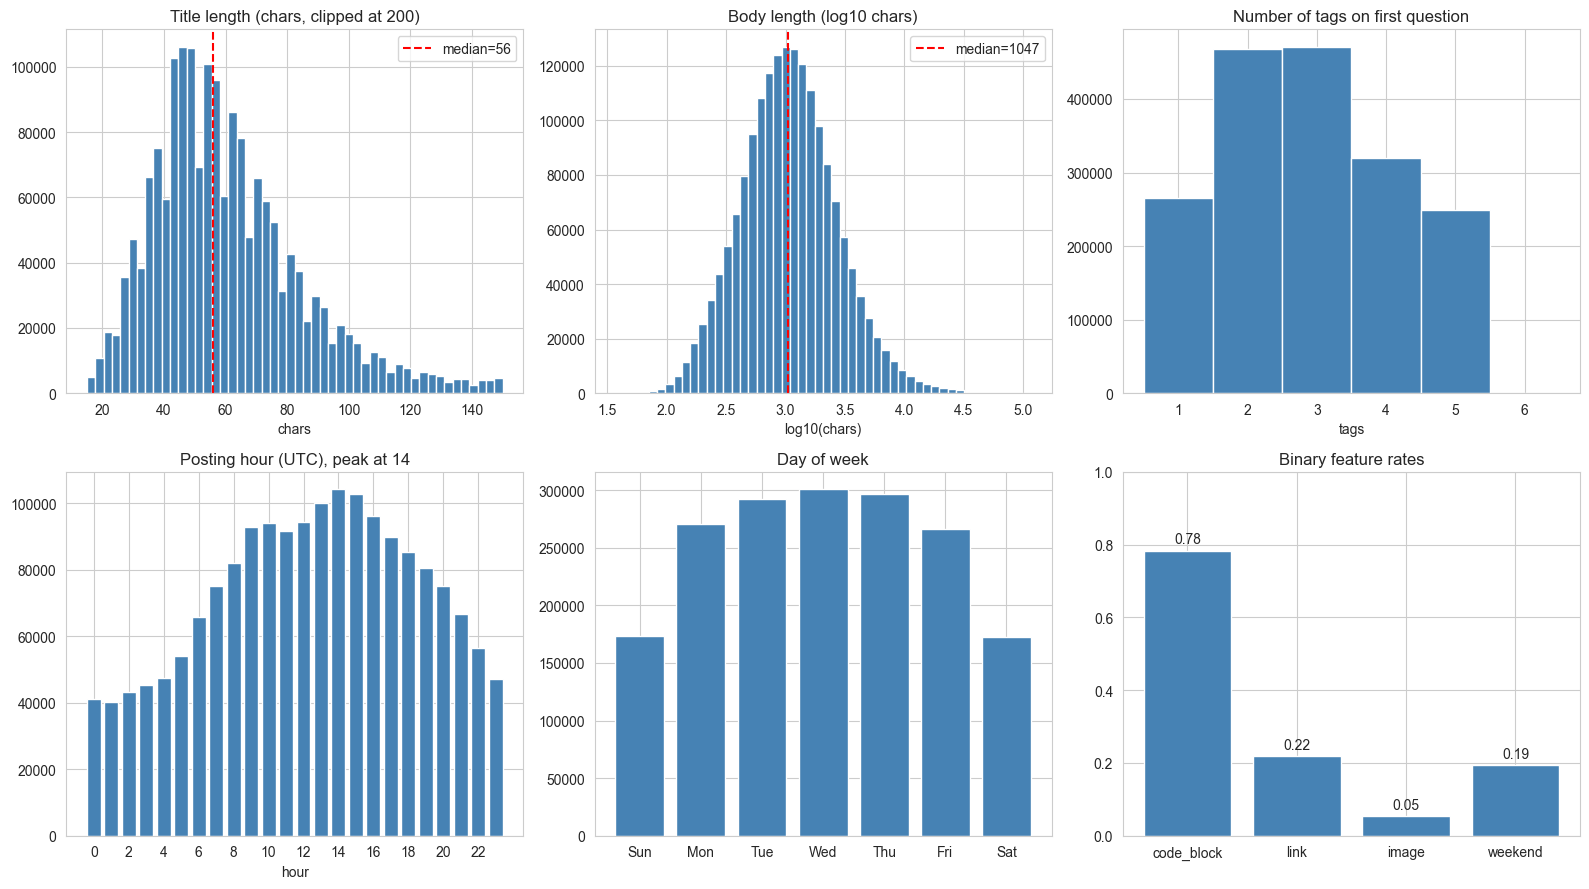

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

axes[0].hist(master['title_length'].clip(upper=200), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(master['title_length'].median(), color='red', linestyle='--',
                label=f"median={int(master['title_length'].median())}")
axes[0].set_title('Title length (chars, clipped at 200)')
axes[0].set_xlabel('chars'); axes[0].legend()

axes[1].hist(np.log10(master['body_length'].clip(lower=1)), bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(np.log10(master['body_length'].median()), color='red', linestyle='--',
                label=f"median={int(master['body_length'].median())}")
axes[1].set_title('Body length (log10 chars)')
axes[1].set_xlabel('log10(chars)'); axes[1].legend()

axes[2].hist(master['num_tags'], bins=range(1, 8), color='steelblue', edgecolor='white', align='left')
axes[2].set_title('Number of tags on first question')
axes[2].set_xlabel('tags'); axes[2].set_xticks(range(1, 7))

hourly = master.groupby('hour_of_day_utc').size()
axes[3].bar(hourly.index, hourly.values, color='steelblue')
axes[3].set_title('Posting hour (UTC), peak at 14')
axes[3].set_xlabel('hour'); axes[3].set_xticks(range(0, 24, 2))

dow_names = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
dow_counts = master.groupby('day_of_week').size().reindex(range(1, 8), fill_value=0)
axes[4].bar(dow_names, dow_counts.values, color='steelblue')
axes[4].set_title('Day of week')

binary = pd.Series({
    'code_block': master['has_code_block'].mean(),
    'link': master['has_link'].mean(),
    'image': master['has_image'].mean(),
    'weekend': master['is_weekend'].mean(),
})
axes[5].bar(binary.index, binary.values, color='steelblue')
axes[5].set_ylim(0, 1)
axes[5].set_title('Binary feature rates')
for i, v in enumerate(binary.values):
    axes[5].text(i, v + 0.02, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

## 5. Naive treatment vs control

Splitting users by treatment status and reporting raw retention rates is the wrong way to estimate the causal effect of getting an answer. Question quality drives both the treatment (good questions get fast answers) and the outcome (people who write good questions retain anyway), so the naive lift overstates the causal effect.

I'm reporting it here for two reasons. First, it anchors the order of magnitude. Second, it makes concrete why the next notebook bothers with PSM, IPW, and 2SLS.

If the naive lift lands around 15 pp, I'd expect the adjusted estimate in the next notebook to land in the 6 to 10 pp range. If the adjustment doesn't shrink the estimate noticeably, that's itself a finding worth writing up.

In [7]:
def naive_lift(df, treat_col, outcome_col):
    return df.groupby(treat_col)[outcome_col].agg(['mean', 'count'])

print('=== D30 retention by treatment (naive) ===\n')
for col in ['got_any_answer', 'got_answer_within_24h', 'got_answer_within_1h']:
    grp = naive_lift(master, col, 'active_d30')
    treated = grp.loc[1, 'mean']
    control = grp.loc[0, 'mean']
    n_treated = grp.loc[1, 'count']
    n_control = grp.loc[0, 'count']
    lift = (treated - control) * 100
    print(f'{col:25s} | control: {control*100:5.1f}% (n={n_control:>10,}) | treated: {treated*100:5.1f}% (n={n_treated:>10,}) | naive lift: {lift:+5.1f} pp')

print()
print('=== D180 retention by treatment (naive, observable subset) ===\n')
for col in ['got_any_answer', 'got_answer_within_24h', 'got_answer_within_1h']:
    grp = naive_lift(obs, col, 'active_d180')
    treated = grp.loc[1, 'mean']
    control = grp.loc[0, 'mean']
    n_treated = grp.loc[1, 'count']
    n_control = grp.loc[0, 'count']
    lift = (treated - control) * 100
    print(f'{col:25s} | control: {control*100:5.1f}% (n={n_control:>10,}) | treated: {treated*100:5.1f}% (n={n_treated:>10,}) | naive lift: {lift:+5.1f} pp')

print()
print('Note: these are naive comparisons, confounded by question quality.')
print('The next notebook (02_retention_model.ipynb) re-estimates with PSM, IPW, and 2SLS.')

=== D30 retention by treatment (naive) ===

got_any_answer            | control:  14.0% (n=   463,398) | treated:  27.6% (n= 1,308,721) | naive lift: +13.6 pp
got_answer_within_24h     | control:  19.1% (n=   678,385) | treated:  27.1% (n= 1,093,734) | naive lift:  +8.0 pp
got_answer_within_1h      | control:  21.8% (n=   969,831) | treated:  26.7% (n=   802,288) | naive lift:  +4.9 pp

=== D180 retention by treatment (naive, observable subset) ===



got_any_answer            | control:   3.5% (n=   354,395) | treated:   5.1% (n= 1,177,430) | naive lift:  +1.6 pp
got_answer_within_24h     | control:   3.8% (n=   549,414) | treated:   5.3% (n=   982,411) | naive lift:  +1.5 pp
got_answer_within_1h      | control:   4.1% (n=   808,589) | treated:   5.5% (n=   723,236) | naive lift:  +1.4 pp

Note: these are naive comparisons, confounded by question quality.
The next notebook (02_retention_model.ipynb) re-estimates with PSM, IPW, and 2SLS.


## 6. Cohort-month trends

Two questions I want to answer here. Has the monthly cohort size changed over the window? I'd expect a secular decline, Stack Overflow's traffic has been falling since around 2014 and new-user signups along with it. And second, have engagement and retention rates shifted over time, without controlling for anything? I'd expect them to be roughly stable, the platform's mechanics didn't change much over the window.

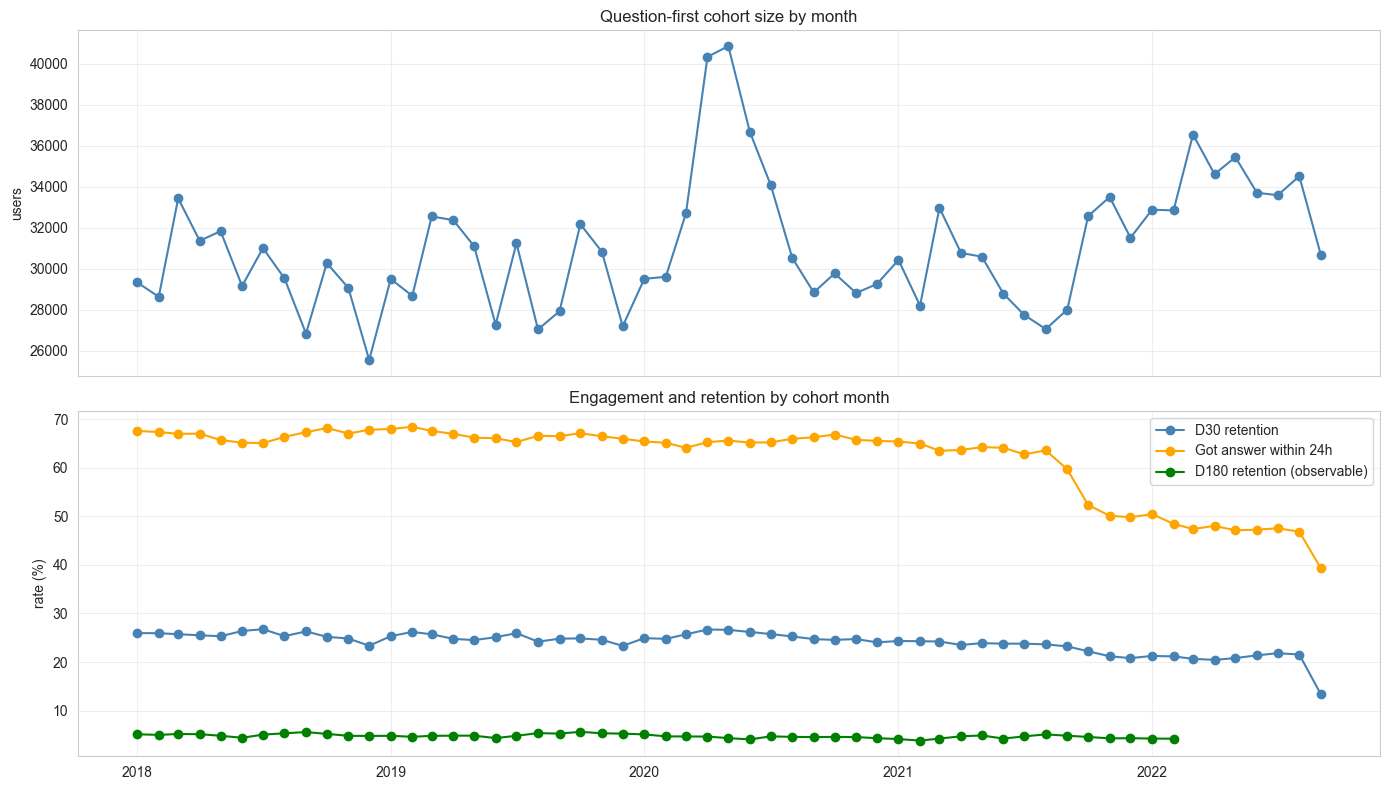


First cohort month: 2018-01-01  (n=29,343)
Last cohort month:  2022-09-01  (n=30,686)
Cohort size: peak=40,856  trough=25,561
D30 retention: min=13.4%  max=26.8%  range=13.4 pp


In [8]:
cohort_agg = master.groupby('cohort_month').agg(
    n=('user_id', 'size'),
    d30_rate=('active_d30', 'mean'),
    code_block_rate=('has_code_block', 'mean'),
    got_24h_rate=('got_answer_within_24h', 'mean'),
).reset_index()

obs_agg = obs.groupby('cohort_month').agg(
    d180_rate_observable=('active_d180', 'mean'),
    n_observable=('user_id', 'size'),
).reset_index()
cohort_agg = cohort_agg.merge(obs_agg, on='cohort_month', how='left')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(cohort_agg['cohort_month'], cohort_agg['n'], marker='o', color='steelblue')
axes[0].set_title('Question-first cohort size by month')
axes[0].set_ylabel('users')
axes[0].grid(alpha=0.3)

axes[1].plot(cohort_agg['cohort_month'], cohort_agg['d30_rate'] * 100, marker='o', label='D30 retention', color='steelblue')
axes[1].plot(cohort_agg['cohort_month'], cohort_agg['got_24h_rate'] * 100, marker='o', label='Got answer within 24h', color='orange')
axes[1].plot(cohort_agg['cohort_month'], cohort_agg['d180_rate_observable'] * 100, marker='o', label='D180 retention (observable)', color='green')
axes[1].set_title('Engagement and retention by cohort month')
axes[1].set_ylabel('rate (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print()
print(f'First cohort month: {cohort_agg["cohort_month"].min()}  (n={cohort_agg.iloc[0]["n"]:,})')
print(f'Last cohort month:  {cohort_agg["cohort_month"].max()}  (n={cohort_agg.iloc[-1]["n"]:,})')
print(f'Cohort size: peak={cohort_agg["n"].max():,}  trough={cohort_agg["n"].min():,}')
print(f'D30 retention: min={cohort_agg["d30_rate"].min()*100:.1f}%  max={cohort_agg["d30_rate"].max()*100:.1f}%  range={cohort_agg["d30_rate"].max()*100 - cohort_agg["d30_rate"].min()*100:.1f} pp')

## 7. Save the master analytics dataset

The downstream notebooks load master.parquet directly rather than rerunning this four-way join.

In [9]:
out_path = f'{DATA_DIR}/master.parquet'
master.to_parquet(out_path, index=False)
size_mb = os.path.getsize(out_path) / 1e6
print(f'Saved: {out_path}')
print(f'  {len(master):,} rows x {master.shape[1]} cols')
print(f'  {size_mb:.1f} MB')

Saved: ../data/processed/master.parquet
  1,772,119 rows x 24 cols
  29.4 MB


## Next, 02_retention_model.ipynb

The next notebook runs four estimators side by side. A naive logistic regression of D30 on treatment plus features. Propensity-score matching on title length, body length, has-code-block, num tags, day of week, and is-weekend. An inverse-probability-weighted regression. And a 2SLS that uses the hour-of-day instrument from sql-05 to identify the causal effect of got_answer_within_24h. All four with bootstrapped standard errors.